# Stage 1: Quadrant Detection

This notebook runs the first stage of the pipeline: detecting which dental quadrant each X-ray belongs to. We load the trained YOLO model, sanity-check its predictions on the test set, then use it to crop every image into its quadrant so Stage 2 (tooth enumeration) has clean, quadrant-aligned crops to work with.

The three functions doing the heavy lifting here, `smart_predict`, `export_enum_by_quad_using_model`, and `analyze_quadrant_predictions`, are utility functions defined in `src/model_utils.py`, not in this notebook. `generate_report` comes from `src/generate_report.py`.

By the end we'll have quadrant crops and prediction logs saved for the train, valid, and test splits, plus a confidence summary flagging any predictions worth a manual look.

In [1]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')
# add the project root to the path so the src package can be imported
sys.path.append(os.path.abspath('..'))

import yaml
from ultralytics import YOLO
from src.utils import apply_smart_aug
from src.model_utils import smart_predict,export_enum_by_quad_using_model,analyze_quadrant_predictions
from src.generate_report import generate_report
import pandas as pd

%matplotlib inline

## Load configs

We'll pull in the stage 1 and stage 2 configs, plus the YOLO data yaml referenced inside stage 1's config. Stage 1 has to load first since its config holds the path to that yaml. The next few cells just print each one out for a quick look.

In [2]:
with open('../configs/stage1.yaml','r') as f:

    stage1_config = yaml.safe_load(f)


with open('../configs/stage2.yaml','r') as f:

    stage2_config = yaml.safe_load(f)


# this path comes from inside stage1_config, so stage1 has to load first
with open(stage1_config['model_args']['data'],'r') as f:

    quad_data_yaml = yaml.safe_load(f)


with open(stage2_config['model_args']['data'],'r') as f:

    enum_data_yaml = yaml.safe_load(f)

In [ ]:
stage1_config

{'paths': {'original_images_path': '../Data/Raw/DENTEX CHALLENGE 2023/Training_data/quadrant/xrays',
  'original_json_path': '../Data/Raw/DENTEX CHALLENGE 2023/Training_data/quadrant/train_quadrant.json',
  's1_main_path': '..\\Data\\Processed\\Stage 1 (Quadrant Detection)',
  'runs_s1_output': '..\\Runs\\Stage 1'},
 'model_args': {'data': '..\\Data\\Processed\\Stage 1 (Quadrant Detection)\\data.yaml',
  'model': '../Models/yolo26s.pt',
  'epochs': 50,
  'save': True,
  'imgsz': 1024,
  'batch': 8,
  'patience': 10,
  'optimizer': 'AdamW',
  'lr0': 0.001,
  'lrf': 0.001,
  'plots': True,
  'verbose': True,
  'device': 'cuda',
  'workers': 4,
  'project': 'Runs',
  'name': 'Stage 1',
  'save_dir': '..\\Runs\\Stage 1',
  'auto_augment': 'None',
  'augment': False,
  'mosaic': 0.0,
  'mixup': 0.0,
  'copy_paste': 0.0,
  'cutmix': 0.0,
  'hsv_h': 0.0,
  'hsv_s': 0.0,
  'hsv_v': 0.0,
  'degrees': 0.0,
  'translate': 0.0,
  'scale': 0.0,
  'shear': 0.0,
  'perspective': 0.0,
  'flipud': 0.0,

In [ ]:
stage2_config

{'paths': {'original_images_path': '../Data/Raw/DENTEX CHALLENGE 2023/Training_data/quadrant-enumeration/xrays',
  'original_json_path': '../Data/Raw/DENTEX CHALLENGE 2023/Training_data/quadrant-enumeration/train_quadrant_enumeration.json',
  's2_main_path': '..\\Data\\Processed\\Stage 2 (Enumeration Detection)',
  'runs_s2_output': '..\\Runs\\Stage 2'},
 'model_args': {'data': '..\\Data\\Processed\\Stage 2 (Enumeration Detection)\\data.yaml'}}

In [ ]:
quad_data_yaml

{'train': 'C:\\Users\\ibrah.HIMA\\OneDrive\\Desktop\\Full AI\\Projects\\GitHub - Kaggle Projects\\dental-xray-ai\\Data\\Processed\\Stage 1 (Quadrant Detection)\\train\\images',
 'val': 'C:\\Users\\ibrah.HIMA\\OneDrive\\Desktop\\Full AI\\Projects\\GitHub - Kaggle Projects\\dental-xray-ai\\Data\\Processed\\Stage 1 (Quadrant Detection)\\valid\\images',
 'test': 'C:\\Users\\ibrah.HIMA\\OneDrive\\Desktop\\Full AI\\Projects\\GitHub - Kaggle Projects\\dental-xray-ai\\Data\\Processed\\Stage 1 (Quadrant Detection)\\test\\images',
 'nc': 4,
 'names': ['Upper Right', 'Upper Left', 'Lower Left', 'Lower Right']}

In [ ]:
enum_data_yaml

## Load the quadrant detection model

We start from the base YOLO checkpoint, then load the weights from the last training run. Training itself already happened, so the training call below is commented out and kept for reference.

In [ ]:
# load the base checkpoint specified in the config, this is the starting point before training
yolo_model = YOLO(stage1_config['model_args']['model'])

In [ ]:
# training already ran once; left here commented out for reference
# yolo_model.train(**stage1_config['model_args'])

In [ ]:
# load the checkpoint saved at the end of training, this is the model we'll actually use for inference
quadrant_model_detection = YOLO(os.path.join(stage1_config['paths']['runs_s1_output'], 'weights', 'last.pt'))

## Sanity-check predictions

Before running this model across the whole dataset, let's look at what it actually predicts on the test set. We'll call `smart_predict` a few times, first plain, then saving the annotated output, then saving cropped quadrants, then comparing against the ground-truth boxes with two different drawing styles.


image 1/1 C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Projects\GitHub - Kaggle Projects\dental-xray-ai\Data\Processed\Stage 1 (Quadrant Detection)\test\images\train_293.png: 512x1024 1 Upper Right, 1 Upper Left, 1 Lower Left, 1 Lower Right, 38.2ms
Speed: 4.3ms preprocess, 38.2ms inference, 0.7ms postprocess per image at shape (1, 3, 512, 1024)
Class Name: Lower Right
Coordinates: [546.8342895507812, 649.4340209960938, 1404.1544189453125, 1101.309814453125]
Confidence: %99.0
Class Name: Upper Right
Coordinates: [593.7418212890625, 297.1649169921875, 1401.1514892578125, 722.9442138671875]
Confidence: %99.0
Class Name: Lower Left
Coordinates: [1394.2191162109375, 677.2001953125, 2192.0322265625, 1108.495849609375]
Confidence: %99.0
Class Name: Upper Left
Coordinates: [1386.4678955078125, 329.2877197265625, 2184.933349609375, 736.3510131835938]
Confidence: %99.0


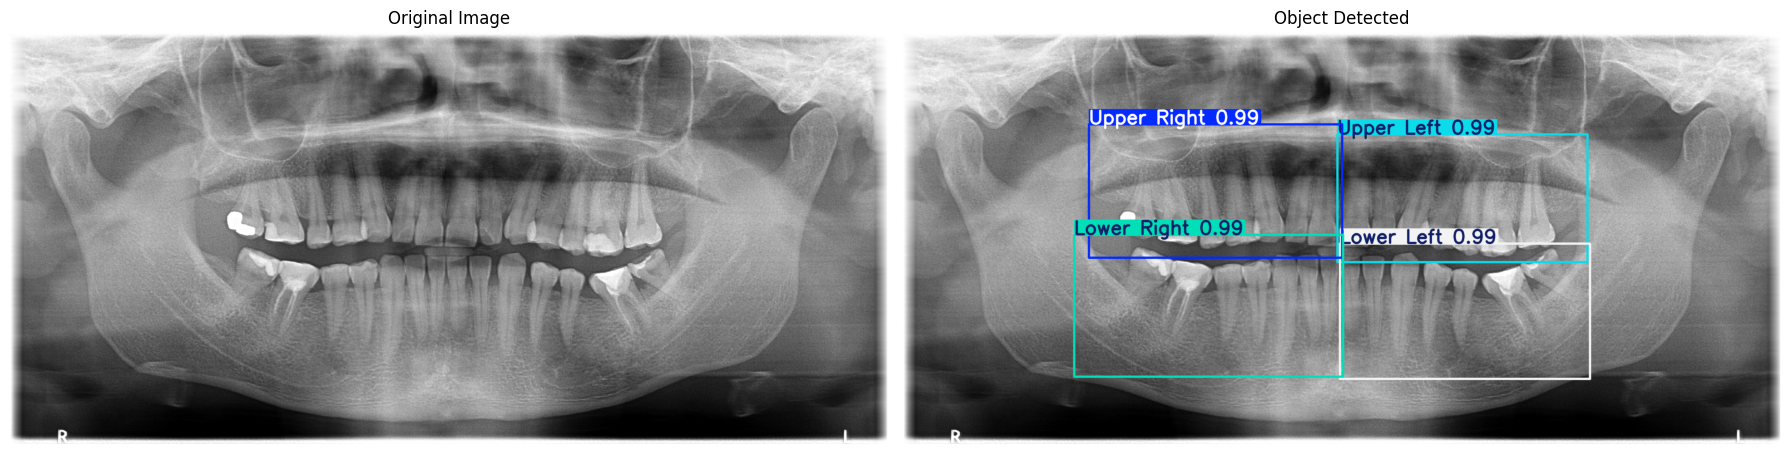

In [ ]:
# run with default settings first, just to confirm the model loads and predicts fine
smart_predict(quadrant_model_detection,quad_data_yaml['test'])


image 1/1 C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Projects\GitHub - Kaggle Projects\dental-xray-ai\Data\Processed\Stage 1 (Quadrant Detection)\test\images\train_284.png: 480x1024 1 Upper Right, 1 Upper Left, 1 Lower Left, 1 Lower Right, 97.1ms
Speed: 14.3ms preprocess, 97.1ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 1024)
Class Name: Upper Left
Coordinates: [1485.734375, 302.140625, 2095.41357421875, 736.197998046875]
Confidence: %99.0
Class Name: Upper Right
Coordinates: [868.2702026367188, 333.8301696777344, 1499.2813720703125, 745.1804809570312]
Confidence: %99.0
Class Name: Lower Right
Coordinates: [770.37548828125, 606.5411987304688, 1521.9359130859375, 1098.299072265625]
Confidence: %99.0
Class Name: Lower Left
Coordinates: [1480.9169921875, 575.22314453125, 2227.69775390625, 1089.81103515625]
Confidence: %98.0


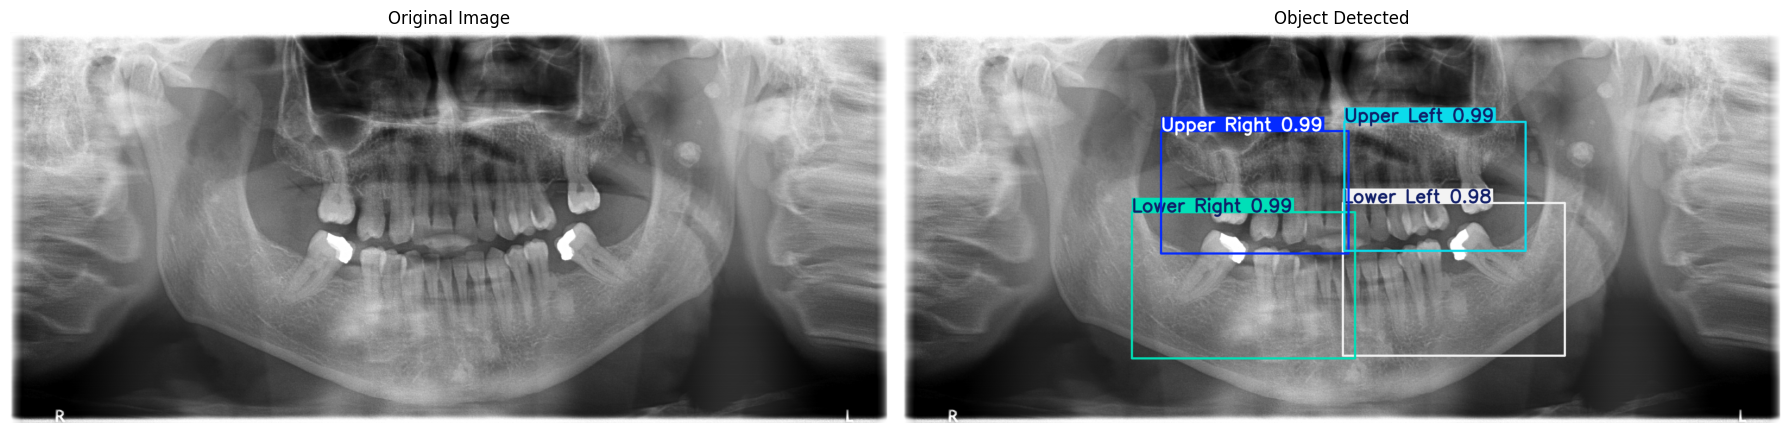

In [ ]:
# same predictions, but save the annotated output images this time
smart_predict(quadrant_model_detection,quad_data_yaml['test'],save_output=True,save_dir=os.path.join(stage1_config['paths']['runs_s1_output'],'Test Outputs Predictions'))


image 1/1 C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Projects\GitHub - Kaggle Projects\dental-xray-ai\Data\Processed\Stage 1 (Quadrant Detection)\test\images\train_241.png: 512x1024 1 Upper Right, 1 Upper Left, 1 Lower Left, 1 Lower Right, 89.8ms
Speed: 5.4ms preprocess, 89.8ms inference, 1.3ms postprocess per image at shape (1, 3, 512, 1024)
Class Name: Lower Left
Coordinates: [1379.4638671875, 573.2013549804688, 2201.747802734375, 1074.2203369140625]
Confidence: %99.0
Class Name: Upper Right
Coordinates: [627.5994873046875, 267.8916931152344, 1382.2191162109375, 672.7194213867188]
Confidence: %99.0
Class Name: Upper Left
Coordinates: [1380.779296875, 255.97640991210938, 2154.52685546875, 675.162353515625]
Confidence: %99.0
Class Name: Lower Right
Coordinates: [569.7120361328125, 573.7730102539062, 1392.9342041015625, 1073.19921875]
Confidence: %98.0


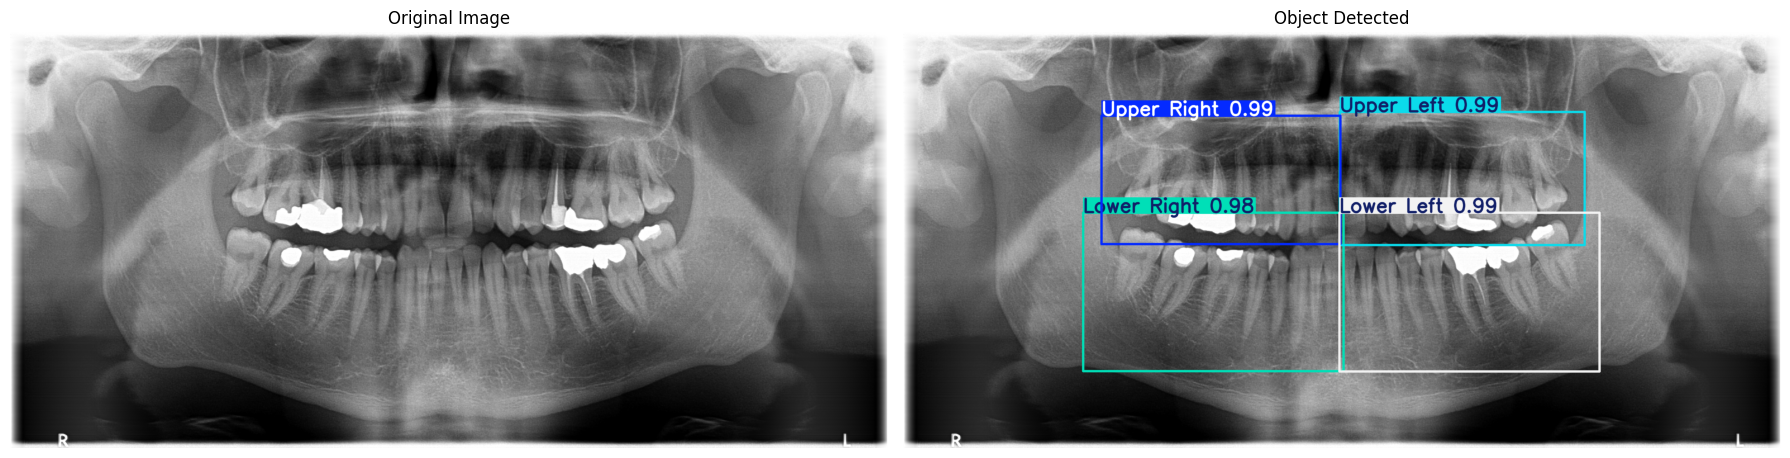

In [ ]:
# save the cropped quadrant images instead of full annotated frames
smart_predict(quadrant_model_detection,quad_data_yaml['test'],save_crop_output_image=True,save_dir=os.path.join(stage1_config['paths']['runs_s1_output'],'Test Outputs Predictions'))


image 1/1 C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Projects\GitHub - Kaggle Projects\dental-xray-ai\Data\Processed\Stage 1 (Quadrant Detection)\test\images\train_512.png: 384x768 1 Upper Right, 1 Upper Left, 1 Lower Left, 1 Lower Right, 75.2ms
Speed: 7.3ms preprocess, 75.2ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 768)
Class Name: Upper Right
Coordinates: [582.27734375, 248.68914794921875, 1371.7080078125, 676.1416625976562]
Confidence: %98.0
Class Name: Lower Right
Coordinates: [515.4501342773438, 559.4495849609375, 1348.3294677734375, 1087.950439453125]
Confidence: %98.0
Class Name: Upper Left
Coordinates: [1356.430419921875, 175.21043395996094, 2185.748779296875, 668.7935180664062]
Confidence: %97.0
Class Name: Lower Left
Coordinates: [1330.3450927734375, 538.5769653320312, 2163.968017578125, 1084.993408203125]
Confidence: %97.0


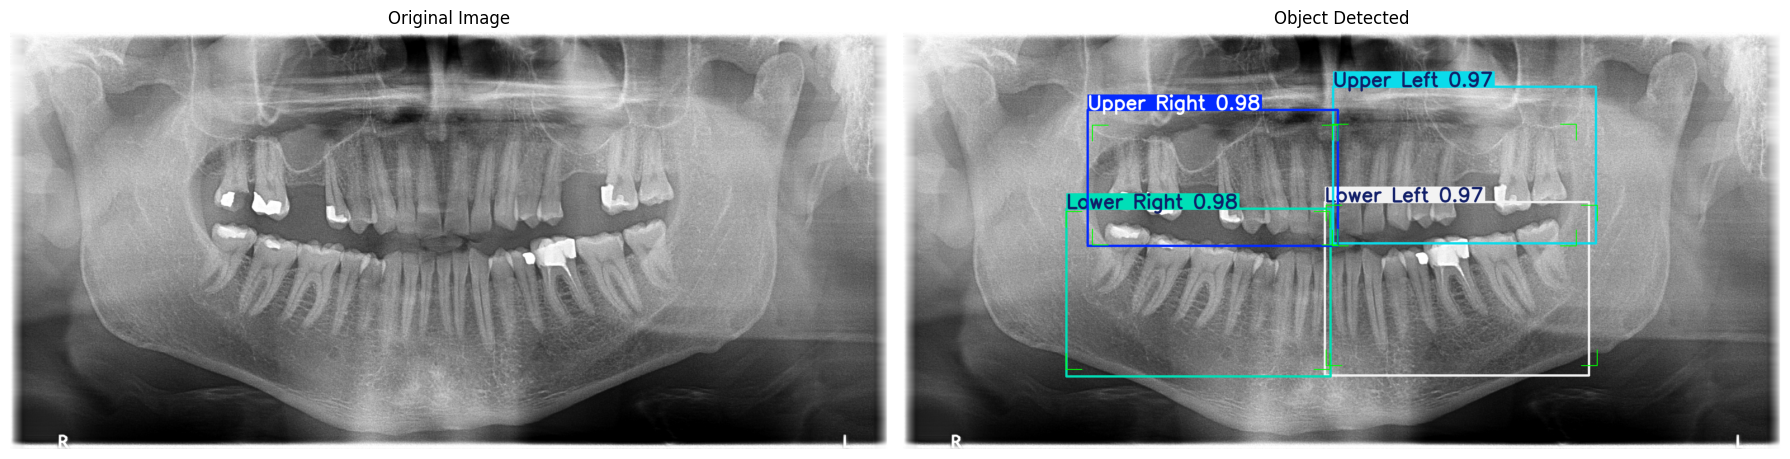

In [ ]:
# overlay the ground-truth boxes next to the predictions for a visual comparison
smart_predict(quadrant_model_detection,quad_data_yaml['test'],show_true_boxes=True)


image 1/1 C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Projects\GitHub - Kaggle Projects\dental-xray-ai\Data\Processed\Stage 1 (Quadrant Detection)\test\images\train_493.png: 480x1024 1 Upper Right, 1 Upper Left, 1 Lower Left, 1 Lower Right, 95.3ms
Speed: 7.9ms preprocess, 95.3ms inference, 0.7ms postprocess per image at shape (1, 3, 480, 1024)
Class Name: Lower Right
Coordinates: [634.0875854492188, 574.842529296875, 1472.606201171875, 1079.396240234375]
Confidence: %99.0
Class Name: Lower Left
Coordinates: [1454.69921875, 603.5469360351562, 2256.822998046875, 1064.6751708984375]
Confidence: %99.0
Class Name: Upper Left
Coordinates: [1466.49853515625, 370.89208984375, 2166.14013671875, 759.9698486328125]
Confidence: %99.0
Class Name: Upper Right
Coordinates: [740.5459594726562, 350.83770751953125, 1471.6507568359375, 768.4490966796875]
Confidence: %99.0


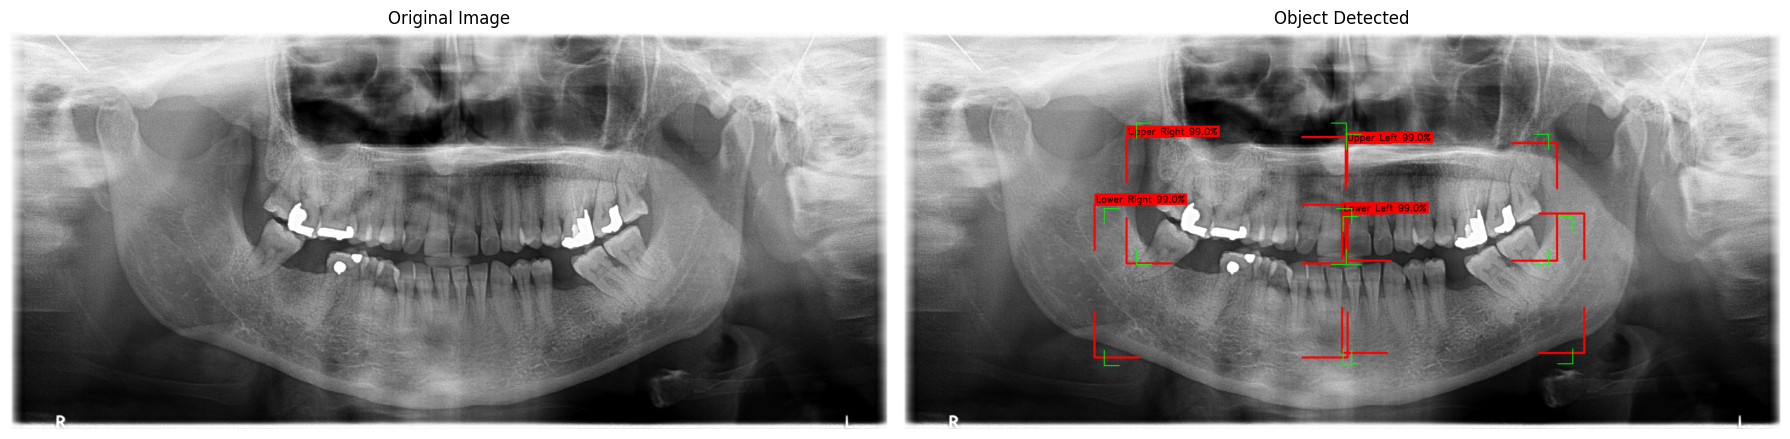

In [ ]:
# same comparison, but using the custom box-drawing style instead of the default one
smart_predict(quadrant_model_detection,quad_data_yaml['test'],show_true_boxes=True,apply_custom_draw_box=True)

In [ ]:
# left disabled for now; uncomment to export a training report PDF
# generate_report(stage1_config['paths']['runs_s1_output'], 
#                 os.path.join(stage1_config['paths']['runs_s1_output'], 'YOLO Training Report (Stage 1).pdf'),
#                 title='YOLO Training Report (Stage 1)')

Report saved to: ..\Runs\Stage 1\YOLO Training Report (Stage 1).pdf


## Prepare Stage 2 data

With the quadrant model checked out, let's move on to preparing the enumeration data for Stage 2. We'll load the pre-split train, valid, and test dataframes and take a quick look at each.

In [ ]:
# these pickles already have the train/valid/test split baked in
train_enum_df = pd.read_pickle(os.path.join(stage2_config['paths']['s2_main_path'], 'train_df (splitted).pkl'))
valid_enum_df = pd.read_pickle(os.path.join(stage2_config['paths']['s2_main_path'], 'valid_df (splitted).pkl'))
test_enum_df = pd.read_pickle(os.path.join(stage2_config['paths']['s2_main_path'], 'test_df (splitted).pkl'))

print('Train Rows:',train_enum_df.shape[0])
print('Valid Rows:',valid_enum_df.shape[0])
print('Test Rows:',test_enum_df.shape[0])

Train Rows: 14357
Valid Rows: 1778
Test Rows: 1830


In [ ]:
train_enum_df.head(3)

,File_Name,Bbox,Height,Width,Enumeration,Quad
0,train_283.png,"[1283.3333333333333, 459.25925925925924, 100.0...",1316,2710,0,Upper Right
1,train_283.png,"[1200.0, 460.18518518518516, 90.74074074074065...",1316,2710,1,Upper Right
2,train_283.png,"[1100.9259259259259, 451.85185185185185, 119.4...",1316,2710,2,Upper Right


In [ ]:
valid_enum_df.head(3)

,File_Name,Bbox,Height,Width,Enumeration,Quad
0,train_187.png,"[1300.0, 483.49514563106794, 104.8543689320388...",1316,2838,0,Upper Right
1,train_187.png,"[1239.8058252427184, 474.75728155339806, 75.72...",1316,2838,1,Upper Right
2,train_187.png,"[1163.1067961165047, 460.19417475728153, 91.26...",1316,2838,2,Upper Right


In [ ]:
test_enum_df.head(3)

,File_Name,Bbox,Height,Width,Enumeration,Quad
0,train_31.png,"[1325.2427184466019, 491.26213592233006, 88.34...",1316,2829,0,Upper Right
1,train_31.png,"[1260.1941747572814, 495.1456310679612, 68.932...",1316,2829,1,Upper Right
2,train_31.png,"[1184.4660194174758, 453.3980582524272, 83.495...",1316,2829,2,Upper Right


## Export quadrant crops

Now we'll use the quadrant model to crop every image into its four quadrants, matched up with the enumeration labels for Stage 2. First, a small debug run on 8 images to make sure everything lines up before running a full split.

Cropping using trained quadrant model:   0%|          | 1/502 [00:00<06:17,  1.33it/s]

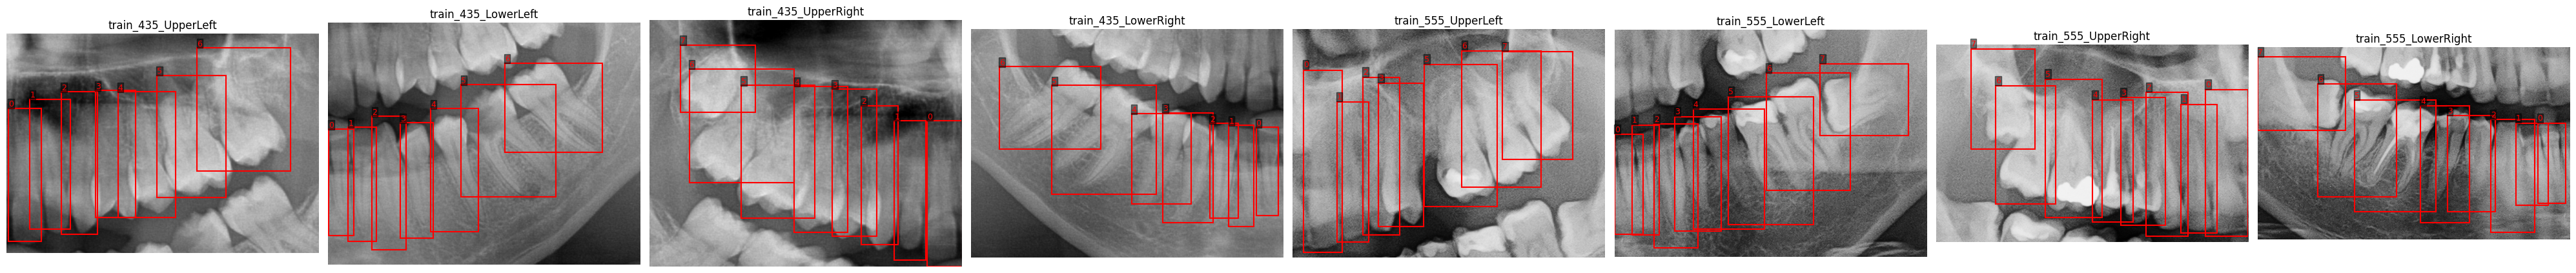

Cropping using trained quadrant model:   0%|          | 1/502 [00:01<14:04,  1.69s/it]


In [ ]:
# debug_limit caps this to 8 images so we can eyeball the crops before running the full split
export_enum_by_quad_using_model(quadrant_model_detection,
                                stage2_config['paths']['original_images_path'],
                                train_enum_df,
                                os.path.join(stage2_config['paths']['s2_main_path'],'train'), 
                                debugging=True,debug_limit=8,)

## Train split

That looks right, so let's run it on the full train split and check the prediction quality with a confidence summary.

In [ ]:
# conf_threshold filters out low-confidence quadrant detections before exporting crops
train_log_df = export_enum_by_quad_using_model(quadrant_model_detection,
                                        stage2_config['paths']['original_images_path'],
                                        train_enum_df,os.path.join(stage2_config['paths']['s2_main_path'], 'train'),
                                        conf_threshold=0.3, verbose=False)

Deleted 4004 files. Failed: 0.


Cropping using trained quadrant model: 100%|██████████| 502/502 [01:51<00:00,  4.51it/s]


Total images processed: 502
Total events logged: 2536



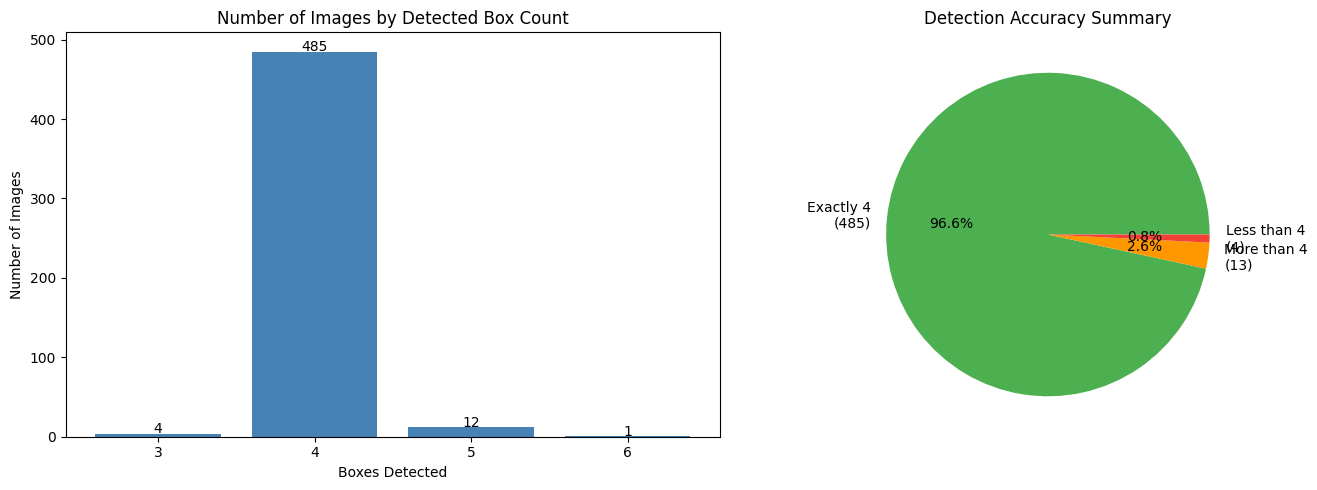

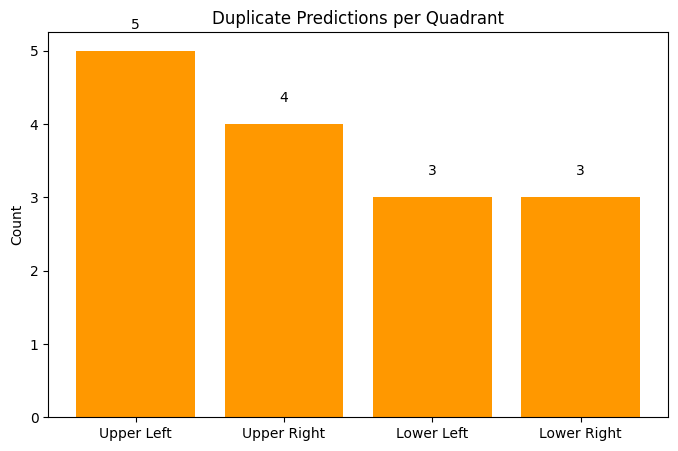

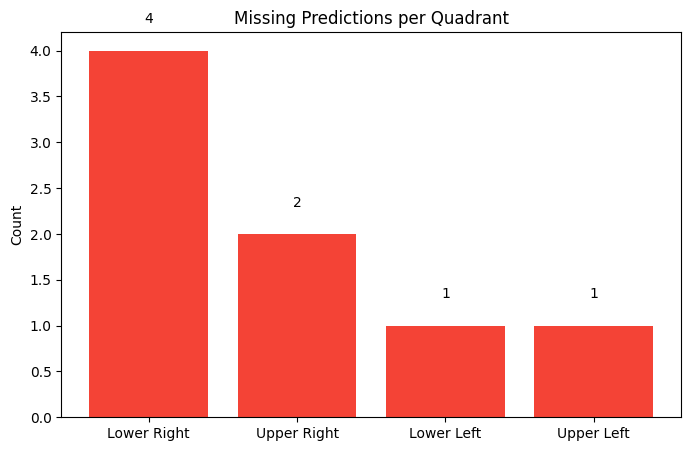

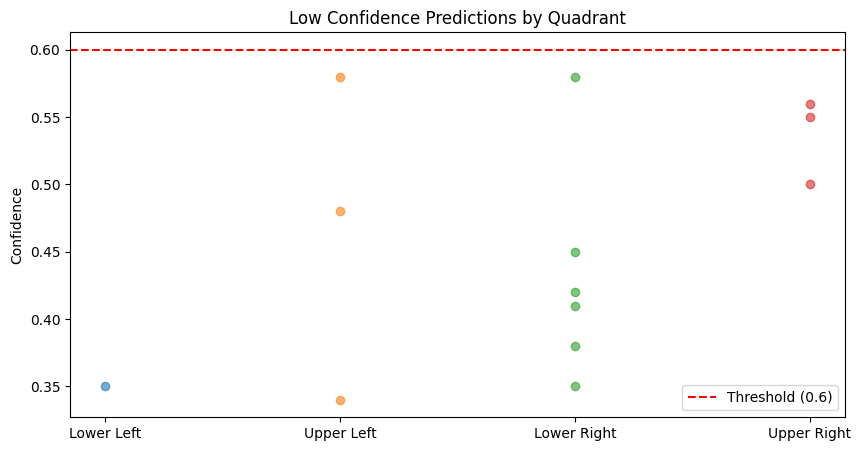


Total low confidence warnings: 13
             count      mean   min
quad                              
Lower Left       1  0.350000  0.35
Lower Right      6  0.431667  0.35
Upper Left       3  0.466667  0.34
Upper Right      3  0.536667  0.50

Average HIGH confidence (>= 0.6): 0.984
Average LOW confidence  (< 0.6): 0.444
Confidence Gap: 0.540  (large, model is inconsistent)


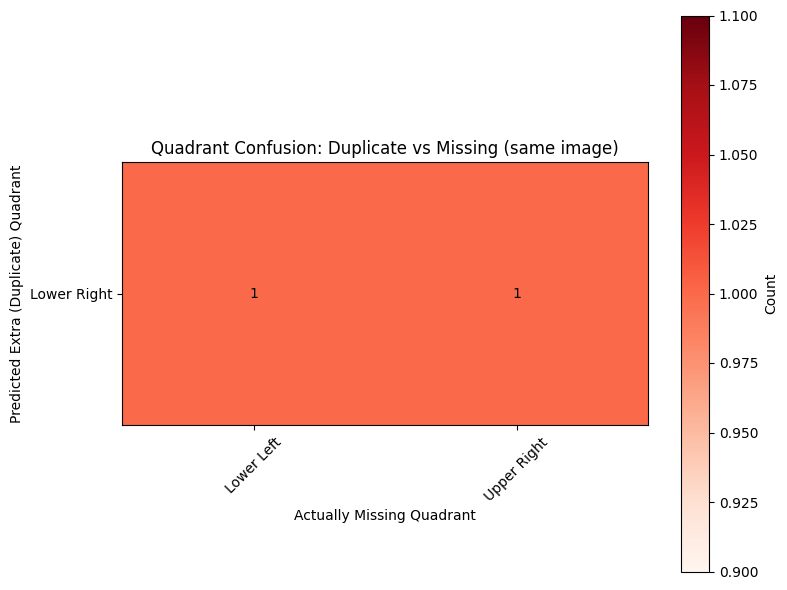


Top 10 problematic images (most warnings):
File_Name
train_273.png    4
train_502.png    2
train_214.png    2
train_174.png    2
train_176.png    1
train_266.png    1
train_255.png    1
train_44.png     1
train_170.png    1
train_615.png    1
Name: count, dtype: int64

Exported worst images log to: worst_train_images.csv


In [ ]:
# flag anything below 0.6 confidence as low-confidence and export the worst ones for manual review
train_log_summary = analyze_quadrant_predictions(train_log_df, low_conf_threshold=0.6, export_worst_csv='worst_train_images.csv')

Quick spot check on two individual train images before moving on to the other splits.

In [ ]:
# spot check two specific train images by filename
smart_predict(quadrant_model_detection,stage2_config['paths']['original_images_path'],'train_273.png')
smart_predict(quadrant_model_detection,stage2_config['paths']['original_images_path'],'train_214.png')

## Valid split

Same steps now for the validation split.

In [ ]:
# same export step as train, now for the validation split
valid_log_df = export_enum_by_quad_using_model(quadrant_model_detection,
                                        stage2_config['paths']['original_images_path'],
                                        valid_enum_df, 
                                        os.path.join(stage2_config['paths']['s2_main_path'], 'valid'),
                                        conf_threshold=0.3, verbose=False)

Cropping using trained quadrant model: 100%|██████████| 64/64 [00:13<00:00,  4.89it/s]


Total images processed: 64
Total events logged: 324



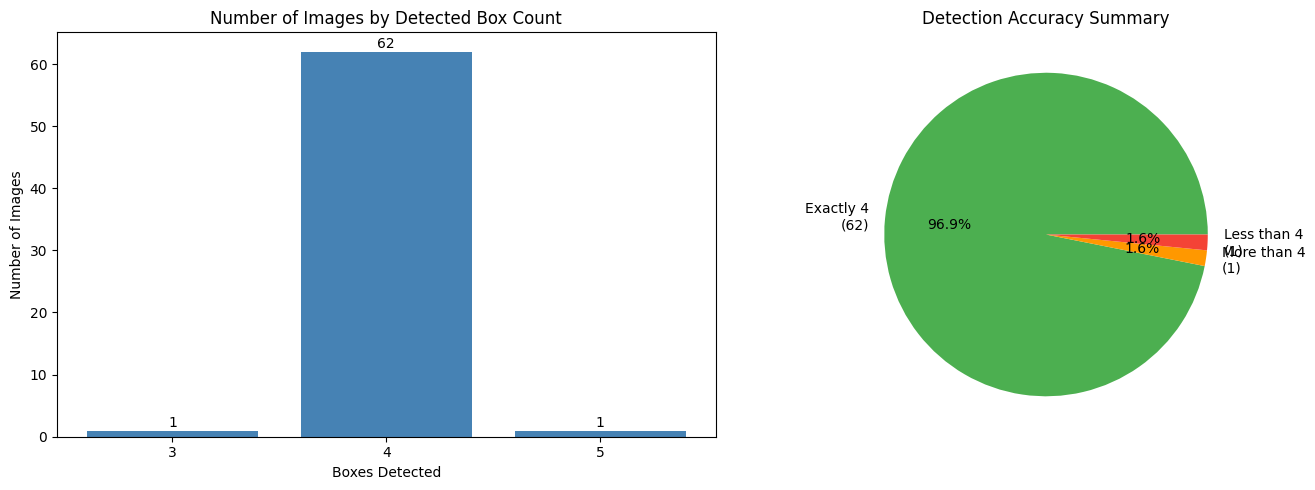

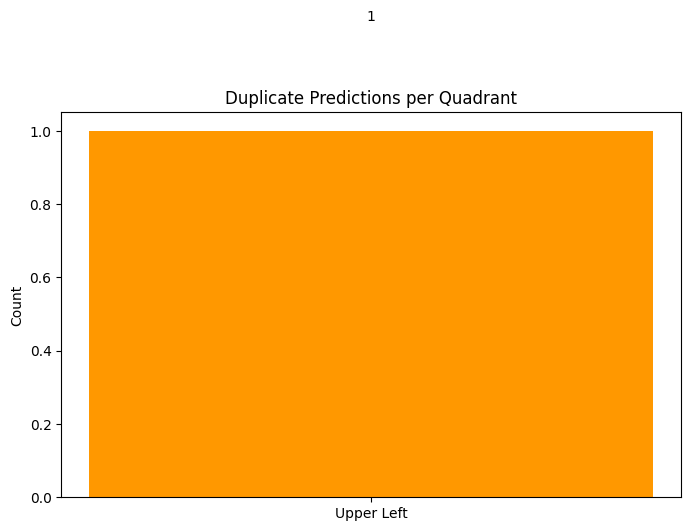

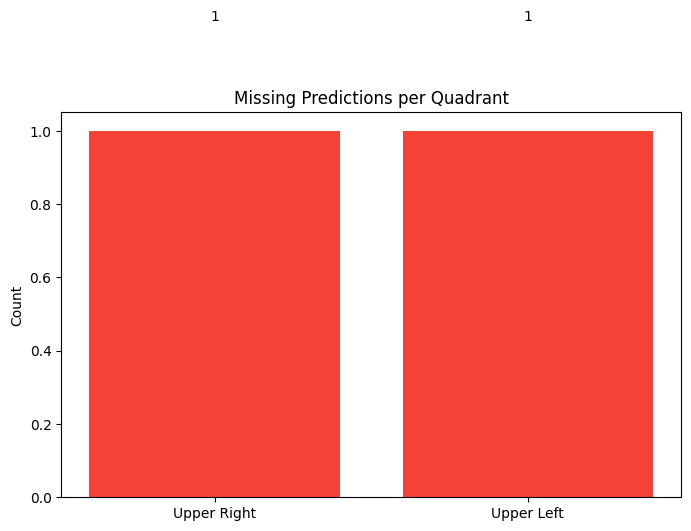

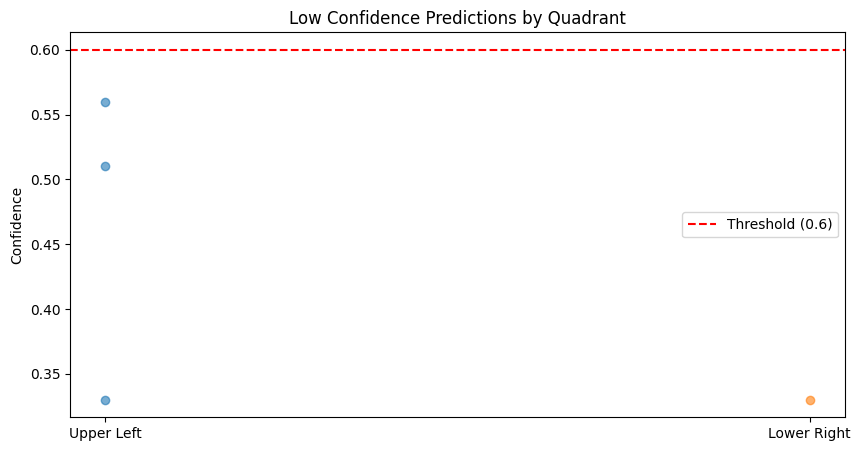


Total low confidence warnings: 4
             count      mean   min
quad                              
Lower Right      1  0.330000  0.33
Upper Left       3  0.466667  0.33

Average HIGH confidence (>= 0.6): 0.985
Average LOW confidence  (< 0.6): 0.427
Confidence Gap: 0.559  (large, model is inconsistent)

No clear duplicate-missing confusion pattern found in the same images.

Top 10 problematic images (most warnings):
File_Name
train_552.png    2
train_101.png    1
train_408.png    1
train_614.png    1
train_633.png    1
Name: count, dtype: int64

Exported worst images log to: worst_valid_images.csv


In [ ]:
# same confidence check, now for validation
valid_log_summary = analyze_quadrant_predictions(valid_log_df, low_conf_threshold=0.6, export_worst_csv='worst_valid_images.csv')

## Test split

And finally the test split.

In [ ]:
# same export step, now for the test split
test_log_df = export_enum_by_quad_using_model(quadrant_model_detection,
                                        stage2_config['paths']['original_images_path'],
                                        test_enum_df, 
                                        os.path.join(stage2_config['paths']['s2_main_path'], 'test'),
                                        conf_threshold=0.3, verbose=False)

Cropping using trained quadrant model: 100%|██████████| 64/64 [00:12<00:00,  4.93it/s]


Total images processed: 64
Total events logged: 323



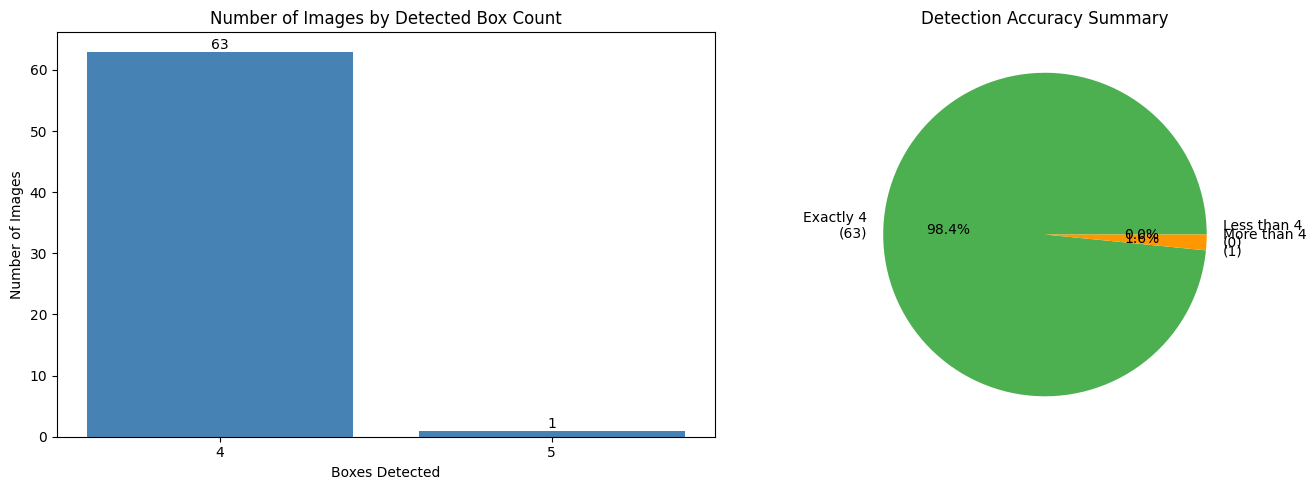

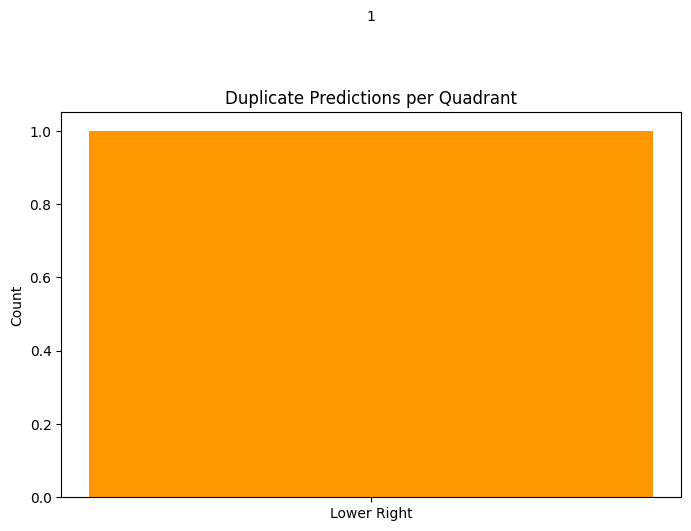

No missing quadrant predictions found.


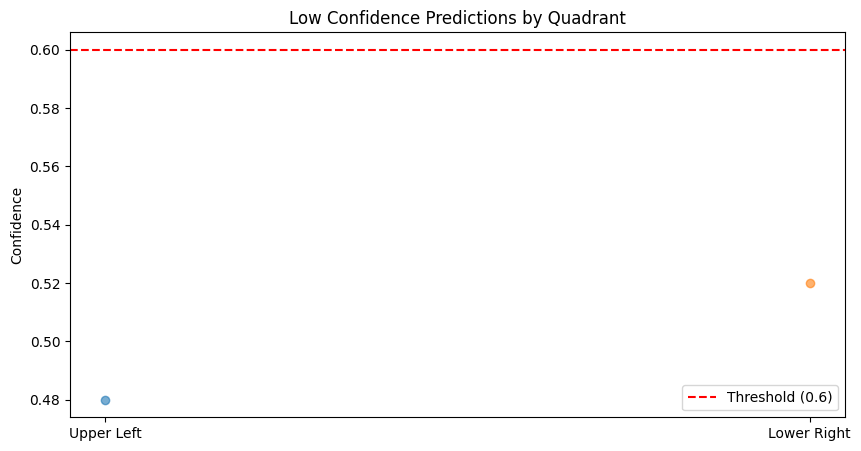


Total low confidence warnings: 2
             count  mean   min
quad                          
Lower Right      1  0.52  0.52
Upper Left       1  0.48  0.48

Average HIGH confidence (>= 0.6): 0.987
Average LOW confidence  (< 0.6): 0.472
Confidence Gap: 0.515  (large, model is inconsistent)

No clear duplicate-missing confusion pattern found in the same images.

Top 10 problematic images (most warnings):
File_Name
train_575.png    2
train_137.png    1
Name: count, dtype: int64

Exported worst images log to: worst_test_images.csv


In [ ]:
# same confidence check, now for test
test_log_summary = analyze_quadrant_predictions(test_log_df, low_conf_threshold=0.6, export_worst_csv='worst_test_images.csv')

In [8]:
ENUM_AUG_CONFIG = {
    'rotate_limit': 6,
    'rotate_p': 0.3,
    'brightness_limit': 0.1,
    'contrast_limit': 0.1,
    'brightness_contrast_p': 0.4,
    'center_crop_ratio': 1.0, # No need to center crop
    'clahe_clip_limit': 2.0,
    'clahe_p': 0.5,
    'resized_crop_scale': (0.9, 1.0),
    'ratio_margin_low': 0.95,
    'ratio_margin_high': 1.05,
    'resized_crop_p': 0.5,
    'min_visibility': 0.4,
}

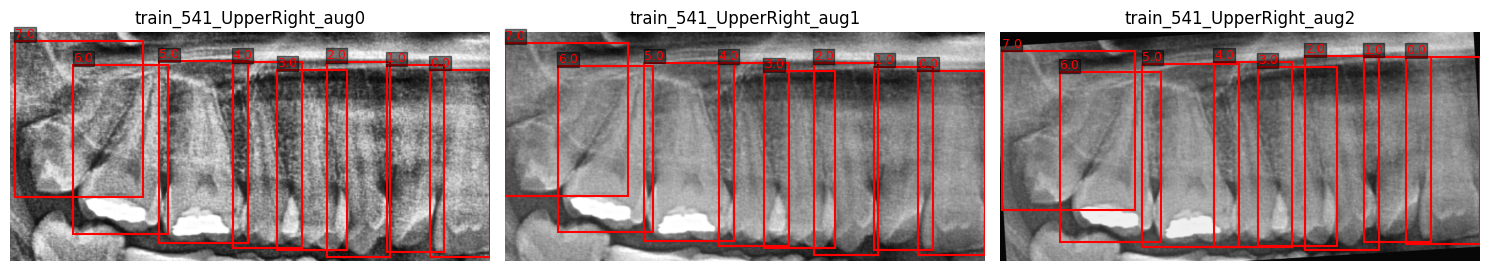

In [13]:
apply_smart_aug(enum_data_yaml,ENUM_AUG_CONFIG,apply_debug=True)